# Dataset description

TODO: Add markdown descriptive text for the notebook.

In [29]:
from pyspark.sql import SparkSession
from pathlib import Path

CLEAN_DATA_DIR = Path("../data/cleaned")

spark = SparkSession.builder.appName("profiling").config("spark.sql.ansi.enabled", "false").config("spark.driver.memory", "16g").getOrCreate()
df = spark.read.parquet(f"{CLEAN_DATA_DIR}/4c_eea_co2_emissions_from_passenger_cars-001.parquet")
df.show(5)

+------------+------------------------+------------------------------------------+----+-----------+--------------------+-----+---------------+--------------------------+-------------------------+---------+---------+---------------------+-----------------+-----------------------------------+----+-------------+
|member_state|vehicle_family_id_number|manufacturer_name_eu_standard_denomination|type|    variant|             version| make|commercial_name|mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|fuel_type|fuel_mode|engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|year|registrations|
+------------+------------------------+------------------------------------------+----+-----------+--------------------+-----+---------------+--------------------------+-------------------------+---------+---------+---------------------+-----------------+-----------------------------------+----+-------------+
|          DE|    IP-MQB48ZZ_A0_084...|                            

In [30]:
from pyspark.sql import functions as F

num_cols = [
    "mass_in_running_order (kg)", "co2_emissions_WLTP (g/km)", 
    "engine_capacity (cm3)", "engine_power (KW)", "electric_energy_consumption (Wh/km)"
]
str_cols = ["member_state", "make", "commercial_name", "fuel_type", "fuel_mode"]
all_cols = str_cols + num_cols

def count_missing(col_name):
    is_missing = F.col(col_name).isNull() | (F.trim(F.col(col_name)) == "")
    return F.sum(is_missing.cast("int")).alias(f"{col_name}_nulls")

def count_zeros(col_name):
    is_zero = F.col(col_name) == 0
    return F.sum(is_zero.cast("int")).alias(f"{col_name}_zeros")

zeros = [count_missing(c) for c in all_cols] + [count_zeros(c) for c in num_cols]

df_zeros = df.groupBy("year").agg(*zeros).orderBy("year")
df_zeros.show(truncate=False)

+----+------------------+----------+---------------------+---------------+---------------+--------------------------------+-------------------------------+---------------------------+-----------------------+-----------------------------------------+--------------------------------+-------------------------------+---------------------------+-----------------------+-----------------------------------------+
|year|member_state_nulls|make_nulls|commercial_name_nulls|fuel_type_nulls|fuel_mode_nulls|mass_in_running_order (kg)_nulls|co2_emissions_WLTP (g/km)_nulls|engine_capacity (cm3)_nulls|engine_power (KW)_nulls|electric_energy_consumption (Wh/km)_nulls|mass_in_running_order (kg)_zeros|co2_emissions_WLTP (g/km)_zeros|engine_capacity (cm3)_zeros|engine_power (KW)_zeros|electric_energy_consumption (Wh/km)_zeros|
+----+------------------+----------+---------------------+---------------+---------------+--------------------------------+-------------------------------+---------------------------

In [31]:
before = df.count()
# clean the dataset, str cols cannot be na
df = df.na.drop(subset=str_cols)
# these columns introduce verbosity and so are not needed, make contains duplicates, fuel_mode, type, variant not necessary for our analysis
not_needed = ["vehicle_family_id_number", "version", "make", "fuel_mode", "type", "variant"]
df = df.drop(*not_needed)
df.select("year").distinct().show(), print(f"dropped {before - df.count()} rows, {df.count()} rows left")

+----+
|year|
+----+
|2023|
|2022|
|2021|
|2018|
|2015|
|2013|
|2014|
|2019|
|2016|
|2017|
|2020|
+----+

dropped 280189 rows, 71003591 rows left


(None, None)

In [32]:
# there are many fuel types entered in many different ways, we have to merge them
df.select("fuel_type").distinct().count(), df.select("fuel_type").distinct().show(100)

+--------------------+
|           fuel_type|
+--------------------+
|            ELECTRIC|
|     PETROL/ELECTRIC|
|     diesel/electric|
|                 e85|
|              diesel|
|     DIESEL/ELECTRIC|
|              petrol|
|              DIESEL|
|              PETROL|
|                  ng|
|                 LPG|
|                 lpg|
|     petrol/electric|
|                  NG|
|            electric|
|            hydrogen|
|             UNKNOWN|
|            HYDROGEN|
|       NG-BIOMETHANE|
|     petrol-electric|
|     Petrol/Electric|
|           Biodiesel|
|         PETROL PHEV|
|              Diesel|
|                 E85|
|     DIESEL-ELECTRIC|
|     Diesel/Electric|
|            Hydrogen|
|       ng-biomethane|
|     Diesel-electric|
|       NG-biomethane|
|     PETROL-ELECTRIC|
|     Diesel-Electric|
|     Petrol-electric|
|            Electric|
|     Petrol-Electric|
|              Petrol|
|     diesel-electric|
|     HYBRID/PETROL/E|
|NG-biomethane    ...|
|DIESEL    

(54, None)

In [33]:
df = df.withColumn("fuel_type", F.lower(F.col("fuel_type")))
df.select("fuel_type").distinct().count(), df.select("fuel_type").distinct().show(100)

+--------------------+
|           fuel_type|
+--------------------+
|     diesel/electric|
|                 e85|
|              diesel|
|              petrol|
|                  ng|
|                 lpg|
|     petrol/electric|
|            electric|
|            hydrogen|
|             unknown|
|       ng-biomethane|
|     petrol-electric|
|     hybrid/petrol/e|
|         petrol phev|
|           biodiesel|
|     diesel-electric|
|lpg              ...|
|               other|
|electric         ...|
|diesel           ...|
|                 cng|
|ng-biomethane    ...|
|             petrol |
|petrol           ...|
|          petrol-gas|
|                 gnl|
+--------------------+



(26, None)

In [34]:
# some values have spaces around them, we don't want those to count as distinct types
df = df.withColumn("fuel_type", F.trim(F.col("fuel_type")))
# some values use dashes and end up duplicating existing value types
df = df.withColumn("fuel_type", F.regexp_replace(F.col("fuel_type"), "-", "/"))
df.select("fuel_type").distinct().count(), df.select("fuel_type").distinct().show(100)

+---------------+
|      fuel_type|
+---------------+
|diesel/electric|
|            e85|
|         diesel|
|         petrol|
|             ng|
|            lpg|
|petrol/electric|
|       electric|
|       hydrogen|
|        unknown|
|  ng/biomethane|
|hybrid/petrol/e|
|    petrol phev|
|      biodiesel|
|          other|
|            cng|
|     petrol/gas|
|            gnl|
+---------------+



(18, None)

In [35]:
unnecessary = ["unknown", "other"]
df = df.filter(~df.fuel_type.isin(unnecessary))
df.select("fuel_type").distinct().count(), df.select("fuel_type").distinct().show(100), print(f"{df.count()} rows left")

+---------------+
|      fuel_type|
+---------------+
|diesel/electric|
|            e85|
|         diesel|
|         petrol|
|             ng|
|            lpg|
|petrol/electric|
|       electric|
|       hydrogen|
|  ng/biomethane|
|hybrid/petrol/e|
|    petrol phev|
|      biodiesel|
|            cng|
|     petrol/gas|
|            gnl|
+---------------+

71003520 rows left


(16, None, None)

In [36]:
# aggregate
df = df.withColumn(
    "fuel_type",
    F.when(F.col("fuel_type") == "electric", "Electricity")
     .when(F.col("fuel_type") == "petrol phev", "Petrol plug-in Hybrid")
     .when(F.col("fuel_type").isin("petrol/electric", "hybrid/petrol/e"), "Petrol hybrid")
     .when(F.col("fuel_type") == "diesel/electric", "Diesel hybrid")
     .when(F.col("fuel_type") == "petrol", "Petrol (excluding hybrids)")
     .when(F.col("fuel_type") == "diesel", "Diesel (excluding hybrids)")
     .otherwise("Alternative/Other") 
)

In [37]:
df.count(), df.show(10)

+------------+------------------------------------------+---------------+--------------------------+-------------------------+--------------------+---------------------+-----------------+-----------------------------------+----+-------------+
|member_state|manufacturer_name_eu_standard_denomination|commercial_name|mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|           fuel_type|engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|year|registrations|
+------------+------------------------------------------+---------------+--------------------------+-------------------------+--------------------+---------------------+-----------------+-----------------------------------+----+-------------+
|          DE|                                     SKODA|         SUPERB|                      1606|                      132|Diesel (excluding...|                 1968|              110|                               NULL|2023|            1|
|          DE|              

(71003520, None)

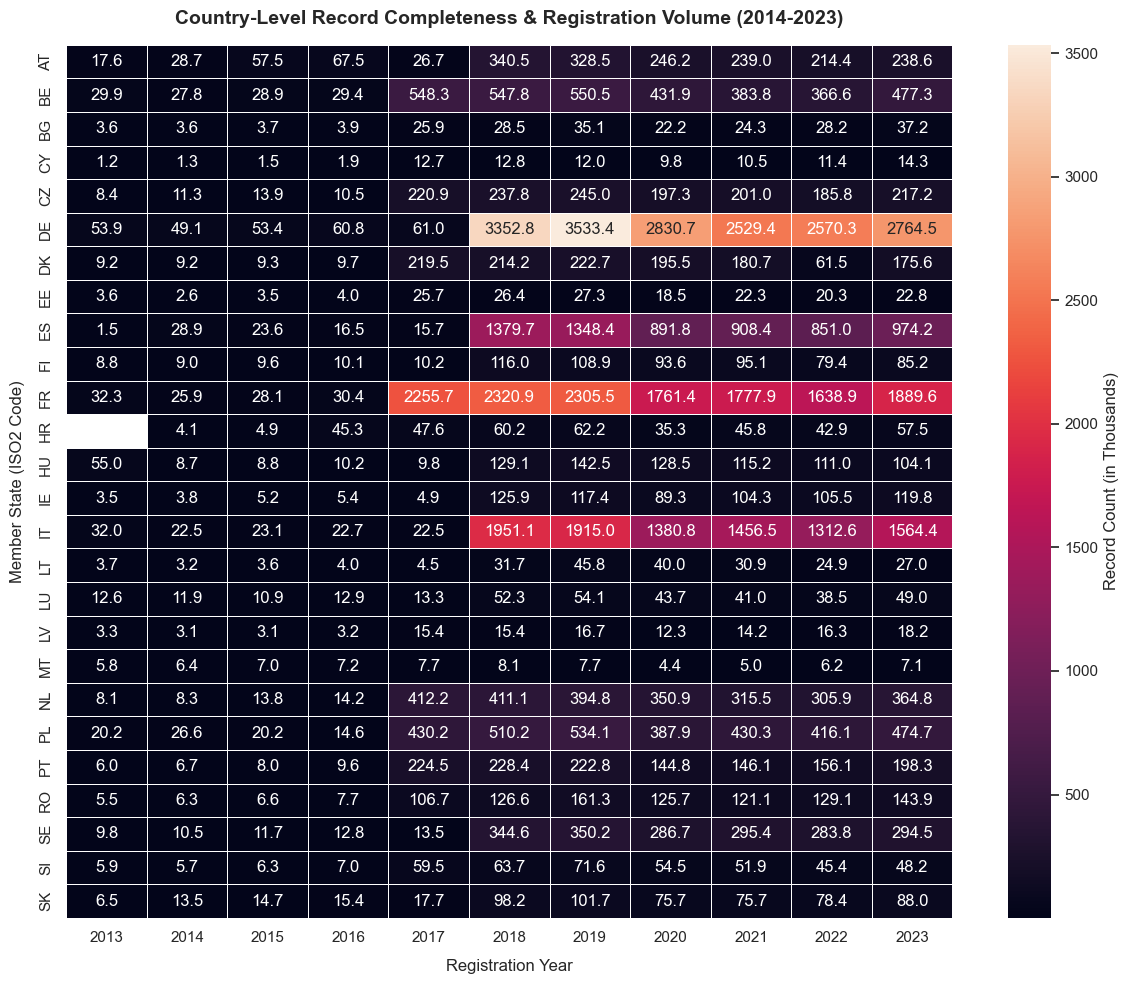

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

df_aggregated = (
    df.groupBy("member_state", "year")
    .agg(
        F.count("*").alias("row_count"),
    )
    .orderBy("member_state", "year")
)

pdf = df_aggregated.toPandas()

pivot_df = pdf.pivot(
    index="member_state", columns="year", values="row_count"
)

pivot_df_k = pivot_df / 1000.0

plt.figure(figsize=(12, 10))
sns.set_theme(style="white")

ax = sns.heatmap(
    pivot_df_k,
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "Record Count (in Thousands)"},
    linewidths=0.5,
    linecolor="white",
)

plt.title(
    "Country-Level Record Completeness & Registration Volume (2014-2023)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Registration Year", fontsize=12, labelpad=10)
plt.ylabel("Member State (ISO2 Code)", fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

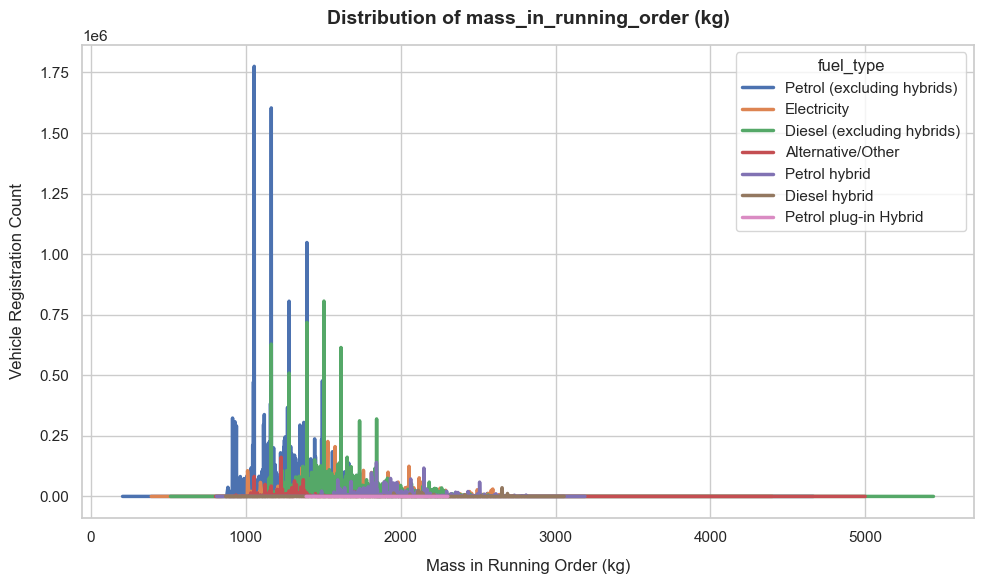

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

target_col = "mass_in_running_order (kg)"
num_bins = 500

stats = (
    df.filter(F.col(target_col).isNotNull())
    .select(F.min(target_col).alias("min_val"), F.max(target_col).alias("max_val"))
    .collect()[0]
)

min_val, max_val = int(stats["min_val"]), int(stats["max_val"])
bin_width = (max_val - min_val) / num_bins

df_binned = (
    df.filter(F.col(target_col).isNotNull())
    .withColumn(
        "bin_center",
        F.floor((F.col(target_col) - min_val) / bin_width) * bin_width
        + min_val
        + (bin_width / 2),
    )
)

hist_counts = (
    df_binned.groupBy("fuel_type", "bin_center")
    .agg(F.count("*").alias("count"))
    .orderBy("bin_center")
)

pdf_hist = hist_counts.toPandas()

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=pdf_hist,
    x="bin_center",
    y="count",
    hue="fuel_type",
    linewidth=2.5,
)

for fuel in pdf_hist["fuel_type"].unique():
    subset = pdf_hist[pdf_hist["fuel_type"] == fuel]
    plt.fill_between(subset["bin_center"], subset["count"], alpha=0.25)

plt.title(
    f"Distribution of {target_col}",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Mass in Running Order (kg)", fontsize=12, labelpad=10)
plt.ylabel("Vehicle Registration Count", fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

In [40]:
# heaviest vehicles
(
    df.filter(F.col("mass_in_running_order (kg)") > 3500)
    .select("manufacturer_name_eu_standard_denomination", "commercial_name", "fuel_type", "mass_in_running_order (kg)")
    .orderBy(F.desc("mass_in_running_order (kg)"))
    .show(20)
)

+------------------------------------------+------------------+--------------------+--------------------------+
|manufacturer_name_eu_standard_denomination|   commercial_name|           fuel_type|mass_in_running_order (kg)|
+------------------------------------------+------------------+--------------------+--------------------------+
|                                    AA-IVA|      SPRINTER 4X4|Diesel (excluding...|                      5440|
|                                    NISSAN|           X-TRAIL|Diesel (excluding...|                      5000|
|                                    AA-IVA|                H2|   Alternative/Other|                      4999|
|                                    AA-IVA|      TM MI 910 GB|Diesel (excluding...|                      4953|
|                                    AA-IVA|             70C18|Diesel (excluding...|                      4925|
|                              OUT OF SCOPE|            TRAFIC|Diesel (excluding...|                    

In [41]:
df.select("registrations").distinct().count(), df.select("registrations").distinct().show(100)

+-------------+
|registrations|
+-------------+
|            1|
|          296|
|          829|
|          675|
|          467|
|         1159|
|         2069|
|         2904|
|         1512|
|         1572|
|         2294|
|         2088|
|          691|
|         2162|
|         1436|
|         1090|
|          125|
|          451|
|          853|
|          944|
|          800|
|         3368|
|         1372|
|         2275|
|         1669|
|         3826|
|         1394|
|          926|
|         1361|
|         1265|
|          666|
|          870|
|          919|
|         2530|
|        12003|
|         1280|
|         1746|
|         2917|
|         2700|
|         7208|
|         6903|
|         2696|
|            7|
|           51|
|          124|
|          591|
|          447|
|         2550|
|         1528|
|         5408|
|         4583|
|         1953|
|         6820|
|         6106|
|          307|
|          574|
|          475|
|         1897|
|          718|
|       

(3713, None)

In [42]:
df.select("manufacturer_name_eu_standard_denomination").distinct().count(), df.select("manufacturer_name_eu_standard_denomination").distinct().orderBy("manufacturer_name_eu_standard_denomination").show(1000, truncate=False)

+------------------------------------------+
|manufacturer_name_eu_standard_denomination|
+------------------------------------------+
|AA-IVA                                    |
|AA-NSS                                    |
|ADIDOR                                    |
|ALFA ROMEO                                |
|ALPINA                                    |
|ALPINE                                    |
|ANHUI                                     |
|ASTON MARTIN                              |
|AUDI AG                                   |
|AUDI HUNGARIA                             |
|AUDI SPORT                                |
|AUTOMOBILES CITROEN                       |
|AUTOMOBILES PEUGEOT                       |
|AVTOVAZ                                   |
|BEE                                       |
|BEE BEE                                   |
|BENTLEY                                   |
|BENTLEY                                   |
|BLUECAR                                   |
|BLUECAR I

(192, None)

In [43]:
# aggregate
df = df.filter(~F.col("manufacturer_name_eu_standard_denomination").isin("DUPLICATE", "OUT OF SCOPE", "UNKNOWN", "duplicate", "unknown"))
df = df.withColumn(
    "manufacturer_name_eu_standard_denomination",
    F.when(F.col("manufacturer_name_eu_standard_denomination") == "AUDI HUNGARIA", "AUDI AG")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "AUDI SPORT", "AUDI AG")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "BEE", "BEE BEE")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "BLUECAR ITALY", "BLUECAR")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "BMW GMBH", "BMW AG")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "DONGFENG LIUZHOU", "DONGFENG")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "DONGFENG MOTOR", "DONGFENG")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "DONKEVOORT", "DONKERVOORT")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "DR MOTOR", "DR AUTOMOBILES")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "Duplicate", "DUPLICATE")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "FORD INDIA", "FORD MOTOR COMPANY")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "FORD MOTOR AUSTRALIA", "FORD MOTOR COMPANY")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "FORD WERKE GMBH", "FORD MOTOR COMPANY")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "Ford Motor Company", "FORD MOTOR COMPANY")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "GENERAL MOTORS COMPANY", "GENERAL MOTORS")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "GENERAL MOTORS HOLDINGS", "GENERAL MOTORS")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "GM ITALIA", "GENERAL MOTORS")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "GM KOREA", "GENERAL MOTORS")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "GM KOREA", "GENERAL MOTORS")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "HONDA CHINA", "HONDA")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "HONDA MOTOR CO", "HONDA")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "HONDA THAILAND", "HONDA")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "HONDA TURKIYE", "HONDA")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "HONDA UK", "HONDA")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "HYUNDAI ASSAN", "HYUNDAI")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "HYUNDAI ASSAN", "HYUNDAI")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "HYUNDAI CZECH", "HYUNDAI")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "HYUNDAI CZECH", "HYUNDAI")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "HYUNDAI EUROPE", "HYUNDAI")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "HYUNDAI INDIA", "HYUNDAI")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "JIANGXI JIANGLING", "JIANGLING MOTOR")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "KIA SLOVAKIA", "KIA")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "KIA SLOVAKIA", "KIA")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "LADA FRANCE", "LADA")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "LANZHOU ZHIDOU", "LANZHOU")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "MAGYAR SUZUKI", "SUZUKI MOTOR CORPORATION")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "MARUTI SUZUKI", "SUZUKI MOTOR CORPORATION")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "MAZDA EUROPE", "MAZDA")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "MERCEDES AMG", "MERCEDES-BENZ AG")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "MERCEDES-AMG", "MERCEDES-BENZ AG")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "NISSAN AUTOMOTIVE EUROPE", "NISSAN")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "OPEL AUTOMOBILE", "OPEL")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "QUATTRO", "AUDI AG")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "RADICAL MOTOSPORT", "RADICAL MOTORSPORT")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "ROLLS-ROYCE", "ROLLS ROYCE")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "SAIC MAXUS", "SAIC MOTOR CORPORATION")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "SAIC MOTOR", "SAIC MOTOR CORPORATION")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "STELLANTIS EUROPE", "STELLANTIS AUTO")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "SUZUKI THAILAND", "SUZUKI MOTOR CORPORATION")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "TOYOTA MOTOR CORPORATION", "TOYOTA")
     .when(F.col("manufacturer_name_eu_standard_denomination") == "WUHAN LOTUS", "LOTUS")
     .otherwise(F.col("manufacturer_name_eu_standard_denomination"))
)
df.select("manufacturer_name_eu_standard_denomination").distinct().count(), df.select("manufacturer_name_eu_standard_denomination").distinct().orderBy("manufacturer_name_eu_standard_denomination").show(1000, truncate=False)

+------------------------------------------+
|manufacturer_name_eu_standard_denomination|
+------------------------------------------+
|AA-IVA                                    |
|AA-NSS                                    |
|ADIDOR                                    |
|ALFA ROMEO                                |
|ALPINA                                    |
|ALPINE                                    |
|ANHUI                                     |
|ASTON MARTIN                              |
|AUDI AG                                   |
|AUTOMOBILES CITROEN                       |
|AUTOMOBILES PEUGEOT                       |
|AVTOVAZ                                   |
|BEE BEE                                   |
|BENTLEY                                   |
|BENTLEY                                   |
|BLUECAR                                   |
|BMW AG                                    |
|BORGWARD                                  |
|BRABUS                                    |
|BRILLIANC

(143, None)

In [44]:
df.select("commercial_name").distinct().count(), df.select("commercial_name").distinct().orderBy("commercial_name").show(1000, truncate=False)

+-----------------------------------------------------+
|commercial_name                                      |
+-----------------------------------------------------+
|                                                     |
|"GIULIA QUADRIFOGLIO ""ALFA ROMEO RACING"""""""      |
|"INS 1,3I ELEG 16""CVT"                              |
|"STELVIO QUADRIFOGLIO "" RACING"""""""               |
|"STELVIO QUADRIFOGLIO ""ALFA ROMEO RACING"""""""     |
|"TOU CUSTOM 17"" 20 EB H1L1 136 320 A6"""            |
|"TOU CUSTOM 17"" 20 EB H1L1 136 320"""               |
|"TOU CUSTOM 17"" 20 EB H1L1 96 320 A6"""             |
|"TOU CUSTOM 17"" 20 EB H1L1 96 320"""                |
|"TOU CUSTOM 17"" 20 EB H1L2 136 320 A6"""            |
|"TOU CUSTOM 17"" 20 EB H1L2 136 320"""               |
|"TOU CUSTOM 17"" 20 EB H1L2 96 320"""                |
|"TOU CUSTOM 17"" 20 EB MHEV H1L1 136 320"""          |
|"TOU CUSTOM 17"" 20 EB MHEV H1L2 136 320"""          |
|"TOU CUSTOM 17"" 20 EB MHEV H1L2 96 320"""     

(33898, None)

In [45]:
duplicates = df.count() - df.distinct().count()
duplicates

68135714

In [46]:
df.groupBy(df.columns) \
  .count() \
  .filter(F.col("count") > 1) \
  .show(truncate=False)

+------------+------------------------------------------+----------------------+--------------------------+-------------------------+-------------+---------------------+-----------------+-----------------------------------+----+-------------+-----+
|member_state|manufacturer_name_eu_standard_denomination|commercial_name       |mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|fuel_type    |engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|year|registrations|count|
+------------+------------------------------------------+----------------------+--------------------------+-------------------------+-------------+---------------------+-----------------+-----------------------------------+----+-------------+-----+
|DE          |MERCEDES-BENZ AG                          |GLC 300 E 4MATIC      |2355                      |13                       |Petrol hybrid|1999                 |150              |213                                |2023|1            |396  |
|DE 

In [47]:
grouping_columns = [col for col in df.columns if col != "registrations"]
df_cleaned = df.groupBy(*grouping_columns) \
               .agg(F.sum("registrations").alias("registrations"))
df_cleaned.show(truncate=False)

+------------+------------------------------------------+-----------------------+--------------------------+-------------------------+-------------+---------------------+-----------------+-----------------------------------+----+-------------+
|member_state|manufacturer_name_eu_standard_denomination|commercial_name        |mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|fuel_type    |engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|year|registrations|
+------------+------------------------------------------+-----------------------+--------------------------+-------------------------+-------------+---------------------+-----------------+-----------------------------------+----+-------------+
|DE          |SEAT                                      |FORMENTOR E-HYBRID     |1680                      |30                       |Petrol hybrid|1395                 |110              |153                                |2023|336.0        |
|DE          |CHRYSLER  

In [48]:
duplicates = df_cleaned.count() - df_cleaned.distinct().count()
duplicates

0

In [49]:
df_cleaned.count()

2167851

In [50]:
# Count rows with 1 registration and rows with more than 1 registration
single_registration_count = df_cleaned.filter(F.col("registrations") == 1).count()
multiple_registration_count = df_cleaned.filter(F.col("registrations") > 1).count()

# Show the counts
print(f"Rows with 1 registration: {single_registration_count}")
print(f"Rows with more than 1 registration: {multiple_registration_count}")

Rows with 1 registration: 695038
Rows with more than 1 registration: 1472813


In [51]:
# Show rows with 1 registration
df_cleaned.filter(F.col("registrations") == 1).show(100, truncate=False)

+------------+------------------------------------------+----------------------------------------+--------------------------+-------------------------+--------------------------+---------------------+-----------------+-----------------------------------+----+-------------+
|member_state|manufacturer_name_eu_standard_denomination|commercial_name                         |mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|fuel_type                 |engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|year|registrations|
+------------+------------------------------------------+----------------------------------------+--------------------------+-------------------------+--------------------------+---------------------+-----------------+-----------------------------------+----+-------------+
|BE          |MERCEDES-BENZ AG                          |S 580 E 4MATIC                          |2440                      |20                       |Petrol hybrid             |

### Rename columns to match the Eurostat dataset

- 'member_state' -> 'geo'
- 'fuel_type' -> 'Motor energy'
- 'year' -> 'TIME_PERIOD'

In [52]:
df_cleaned = df_cleaned.withColumnRenamed("member_state", "geo") \
                       .withColumnRenamed("fuel_type", "Motor energy") \
                       .withColumnRenamed("year", "TIME_PERIOD")
df_cleaned.show(5, truncate=False)

+---+------------------------------------------+------------------+--------------------------+-------------------------+-------------+---------------------+-----------------+-----------------------------------+-----------+-------------+
|geo|manufacturer_name_eu_standard_denomination|commercial_name   |mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|Motor energy |engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|TIME_PERIOD|registrations|
+---+------------------------------------------+------------------+--------------------------+-------------------------+-------------+---------------------+-----------------+-----------------------------------+-----------+-------------+
|DE |SEAT                                      |FORMENTOR E-HYBRID|1680                      |30                       |Petrol hybrid|1395                 |110              |153                                |2023       |336.0        |
|DE |CHRYSLER                                  |RENE

### Add 'Geopolitical entity (reporting)' column to match the Eurostat dataset

In [53]:
import country_converter as coco

df_cleaned = df_cleaned.withColumn("Geopolitical entity (reporting)", F.udf(lambda x: coco.convert(names=x, to='name_short', not_found=None))(F.col("geo")))
df_cleaned.show(5, truncate=False)

+---+------------------------------------------+------------------+--------------------------+-------------------------+-------------+---------------------+-----------------+-----------------------------------+-----------+-------------+-------------------------------+
|geo|manufacturer_name_eu_standard_denomination|commercial_name   |mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|Motor energy |engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|TIME_PERIOD|registrations|Geopolitical entity (reporting)|
+---+------------------------------------------+------------------+--------------------------+-------------------------+-------------+---------------------+-----------------+-----------------------------------+-----------+-------------+-------------------------------+
|DE |SEAT                                      |FORMENTOR E-HYBRID|1680                      |30                       |Petrol hybrid|1395                 |110              |153                

### Cast 'registrations' column to IntegerType

In [54]:
df_cleaned = df_cleaned.withColumn("registrations", F.col("registrations").cast("integer"))
df_cleaned.show(5, truncate=False)

+---+------------------------------------------+------------------+--------------------------+-------------------------+-------------+---------------------+-----------------+-----------------------------------+-----------+-------------+-------------------------------+
|geo|manufacturer_name_eu_standard_denomination|commercial_name   |mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|Motor energy |engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|TIME_PERIOD|registrations|Geopolitical entity (reporting)|
+---+------------------------------------------+------------------+--------------------------+-------------------------+-------------+---------------------+-----------------+-----------------------------------+-----------+-------------+-------------------------------+
|DE |SEAT                                      |FORMENTOR E-HYBRID|1680                      |30                       |Petrol hybrid|1395                 |110              |153                

### Reorder columns to match the Eurostat dataset

In [56]:
# Reoder columns to match the Eurostat dataset
df_cleaned = df_cleaned.select(
    "geo",
    "Geopolitical entity (reporting)",
    "TIME_PERIOD",
    "registrations",
    "manufacturer_name_eu_standard_denomination",
    "commercial_name",
    "Motor energy",
    "mass_in_running_order (kg)",
    "co2_emissions_WLTP (g/km)",
    "engine_capacity (cm3)",
    "engine_power (KW)",
    "electric_energy_consumption (Wh/km)"
)
df_cleaned.show(5, truncate=False)

+---+-------------------------------+-----------+-------------+------------------------------------------+------------------+-------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
|geo|Geopolitical entity (reporting)|TIME_PERIOD|registrations|manufacturer_name_eu_standard_denomination|commercial_name   |Motor energy |mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|
+---+-------------------------------+-----------+-------------+------------------------------------------+------------------+-------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
|DE |Germany                        |2023       |336          |SEAT                                      |FORMENTOR E-HYBRID|Petrol hybrid|1680                      |30                       |1